I am exploring the columns [Tot_Benes, Tot_Srvcs, Tot_Sbmtd_Chrg, Med_Tot_Benes, Med_Tot_Srvcs, Med_Sbmtd_Chrg, Bene_Race_Wht_Cnt, Bene_Race_Black_Cnt, Bene_Race_API_Cnt, Bene_Race_Hspnc_Cnt, Bene_Race_NatInd_Cnt, Bene_Race_Othr_Cnt] in the 

In [1]:
file_path = "../data/raw/Modified_Prov_Type_and_Round_Int_All_10_years.csv"

In [2]:
import pandas as pd

columns_to_keep = [
    "Tot_Benes",
    "Tot_Srvcs",
    "Tot_Sbmtd_Chrg",
    "Med_Tot_Benes",
    "Med_Tot_Srvcs",
    "Med_Sbmtd_Chrg",
    "Bene_Race_Wht_Cnt",
    "Bene_Race_Black_Cnt",
    "Bene_Race_API_Cnt",
    "Bene_Race_Hspnc_Cnt",
    "Bene_Race_NatInd_Cnt",
    "Bene_Race_Othr_Cnt"
]

df = pd.read_csv(
    file_path,
    usecols=columns_to_keep,
    low_memory=False
)

df.shape

(12232194, 12)

In [4]:
df["Charge_per_Bene"] = df["Tot_Sbmtd_Chrg"] / df["Tot_Benes"]
df["Charge_per_Service"] = df["Tot_Sbmtd_Chrg"] / df["Tot_Srvcs"]

df["Med_Charge_per_Bene"] = df["Med_Sbmtd_Chrg"] / df["Med_Tot_Benes"]
df["Med_Charge_per_Service"] = df["Med_Sbmtd_Chrg"] / df["Med_Tot_Srvcs"]

df[[
    "Tot_Benes",
    "Tot_Srvcs",
    "Tot_Sbmtd_Chrg",
    "Charge_per_Bene",
    "Charge_per_Service"
]].describe()

,Tot_Benes,Tot_Srvcs,Tot_Sbmtd_Chrg,Charge_per_Bene,Charge_per_Service
count,1.223219e+07,1.223219e+07,1.223219e+07,1.223219e+07,1.223219e+07
mean,3.400330e+02,2.678288e+03,3.486567e+05,1.186761e+03,3.630503e+02
std,2.999759e+03,4.302045e+04,2.670467e+06,4.552863e+03,7.134257e+02
min,1.100000e+01,1.000000e+01,1.100000e-01,1.000000e-02,1.000000e-02
25%,6.100000e+01,1.770000e+02,3.228109e+04,3.448667e+02,9.104268e+01
50%,1.580000e+02,5.040000e+02,1.094921e+05,6.604930e+02,1.690581e+02
75%,3.500000e+02,1.471000e+03,3.059400e+05,1.261733e+03,3.547066e+02
max,1.785552e+06,3.465613e+07,1.218401e+09,2.279466e+06,9.157107e+04


Per-beneficiary submitted charges are heavily right-skewed, with a small number of providers exhibiting extremely high spending intensity. The median charge per beneficiary is $660, while the mean is nearly $1,200, indicating substantial upper-tail influence.

In [10]:
df["Charge_per_Bene"].skew()

np.float64(140.54220290289962)

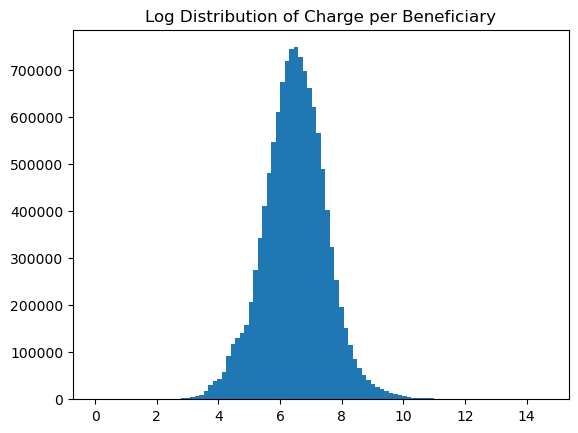

In [8]:
import numpy as np

plt.hist(np.log1p(df["Charge_per_Bene"]), bins=100)
plt.title("Log Distribution of Charge per Beneficiary")
plt.show()

In [6]:
race_cols = [
    "Bene_Race_Wht_Cnt",
    "Bene_Race_Black_Cnt",
    "Bene_Race_API_Cnt",
    "Bene_Race_Hspnc_Cnt",
    "Bene_Race_NatInd_Cnt",
    "Bene_Race_Othr_Cnt"
]

df["Total_Race_Count"] = df[race_cols].sum(axis=1)

for col in race_cols:
    df[col.replace("_Cnt", "_Pct")] = df[col] / df["Total_Race_Count"]

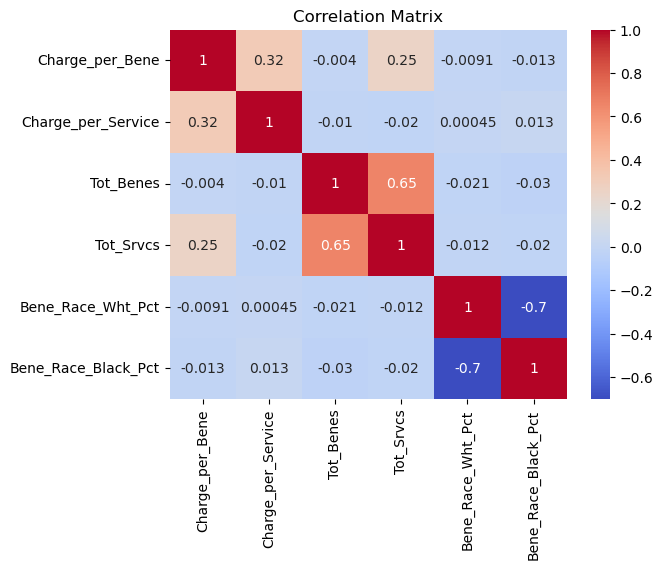

In [7]:
import seaborn as sns

corr = df[[
    "Charge_per_Bene",
    "Charge_per_Service",
    "Tot_Benes",
    "Tot_Srvcs",
    "Bene_Race_Wht_Pct",
    "Bene_Race_Black_Pct"
]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

From this correlation matrix we cna see total beneficiaries and total services has a strong positive correlation indicating bigger providers do more services. Higher volumes slighly correlate with higher charges per beneficiary. Finally, race percentages have near zero correlations so racial composition is not strongly linearly associated with spending intensity.

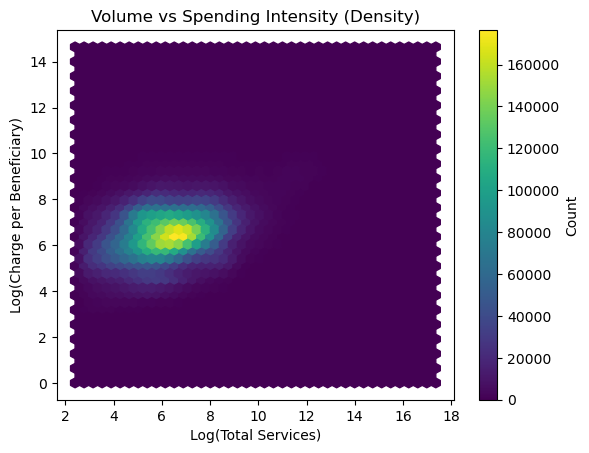

In [19]:
plt.hexbin(
    np.log1p(df["Tot_Srvcs"]),
    np.log1p(df["Charge_per_Bene"]),
    gridsize=40,
    cmap="viridis"
)

plt.xlabel("Log(Total Services)")
plt.ylabel("Log(Charge per Beneficiary)")
plt.title("Volume vs Spending Intensity (Density)")
plt.colorbar(label="Count")
plt.show()

C:\Users\alybo\AppData\Local\Temp\ipykernel_23332\1243169860.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trend = df.groupby("Service_Bin")["Charge_per_Bene"].median()


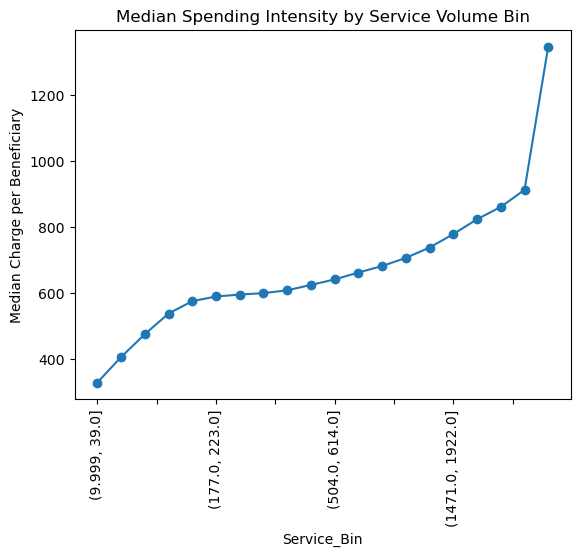

In [20]:
df["Service_Bin"] = pd.qcut(df["Tot_Srvcs"], q=20)

trend = df.groupby("Service_Bin")["Charge_per_Bene"].median()

trend.plot(marker="o")
plt.xticks(rotation=90)
plt.ylabel("Median Charge per Beneficiary")
plt.title("Median Spending Intensity by Service Volume Bin")
plt.show()

While there is a modest positive association between service volume and per-beneficiary charges, the relationship is weak relative to the overall variance. This suggests that volume alone is insufficient to explain spending intensity.

In [12]:
df["Medicare_Share"] = df["Med_Sbmtd_Chrg"] / df["Tot_Sbmtd_Chrg"]
df["Medicare_Bene_Share"] = df["Med_Tot_Benes"] / df["Tot_Benes"]

df[["Medicare_Share", "Medicare_Bene_Share"]].describe()

,Medicare_Share,Medicare_Bene_Share
count,1.089768e+07,1.089768e+07
mean,9.517008e-01,9.994201e-01
std,1.571166e-01,1.558211e-02
min,0.000000e+00,0.000000e+00
25%,9.977384e-01,1.000000e+00
50%,1.000000e+00,1.000000e+00
75%,1.000000e+00,1.000000e+00
max,1.000000e+00,1.000000e+00


The dataset appears to be overwhelmingly Medicare-based. Over 50% of providers have 100% of submitted charges attributed to Medicare beneficiaries, and the average Medicare share exceeds 95%. So payer mix modelling would not be useful and differences in spending are likely driven by provider behavoir, specialty, or service intensity.This tells us medicare share probably should not be included in our model.

Our model can cover: Provider-level cost intensity, Volume vs efficiency, Outlier detection, Service concentration patterns

In [24]:
df["Medicare_Share"].max()

df["Medicare_Share"].quantile([0.5, 0.75, 0.9, 0.99])


0.50    1.0
0.75    1.0
0.90    1.0
0.99    1.0
Name: Medicare_Share, dtype: float64

The vast majority of providers derive more than 99% of submitted charges from Medicare beneficiaries.

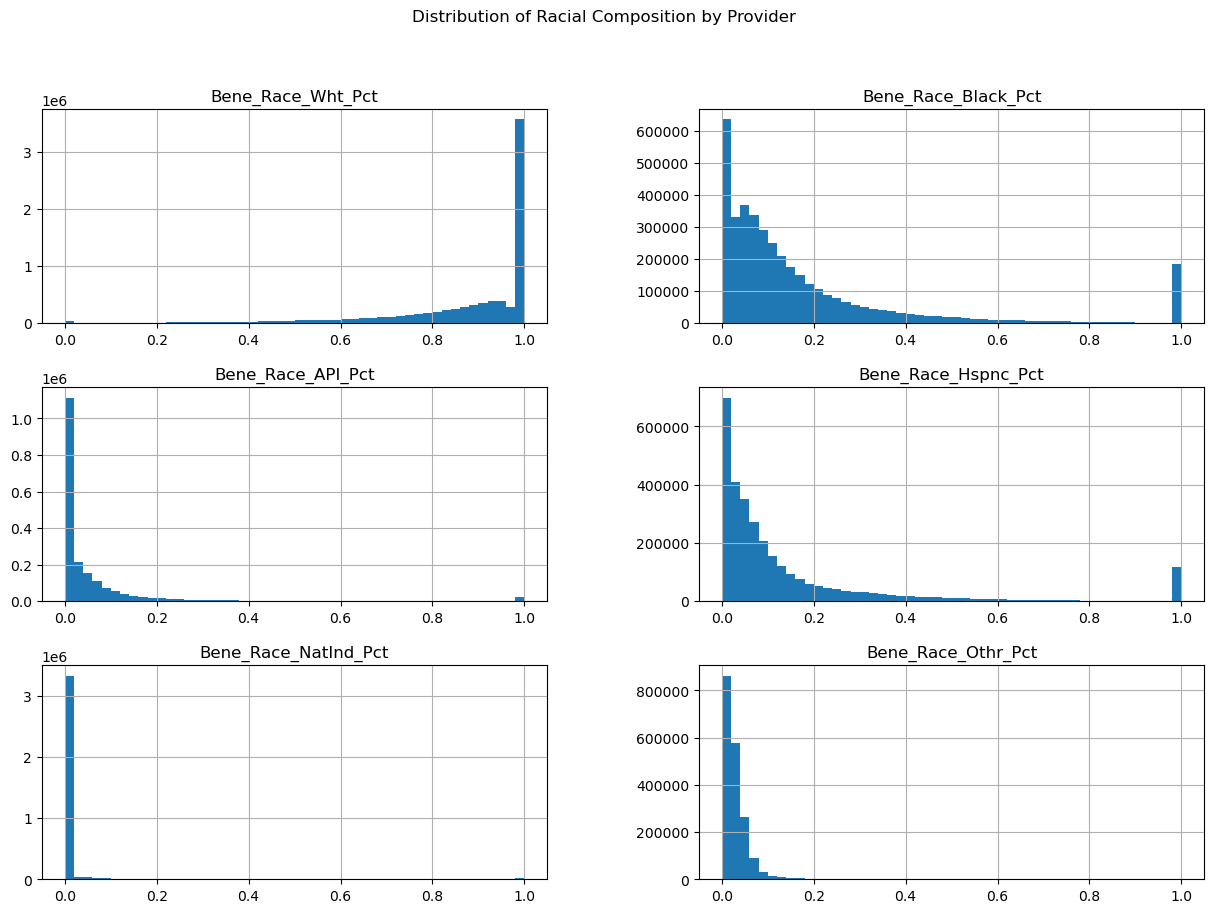

In [27]:
df[race_pct_cols].hist(bins=50, figsize=(15,10))
plt.suptitle("Distribution of Racial Composition by Provider")
plt.show()

In [31]:
weighted_black = df["Bene_Race_Black_Cnt"].sum() / df["Tot_Benes"].sum()
weighted_black

np.float64(0.07584146585475794)

In [29]:
df["Bene_Race_Black_Pct"].mean()

np.float64(0.18262030298123597)

In [30]:
weighted = {}
for col in race_cols:
    weighted[col] = (df[col] * df["Tot_Benes"]).sum() / df["Tot_Benes"].sum()

weighted

{'Bene_Race_Wht_Cnt': np.float64(20845.223128668098),
 'Bene_Race_Black_Cnt': np.float64(2941.766803616626),
 'Bene_Race_API_Cnt': np.float64(769.1798848800694),
 'Bene_Race_Hspnc_Cnt': np.float64(1488.4031562108364),
 'Bene_Race_NatInd_Cnt': np.float64(59.533779440922736),
 'Bene_Race_Othr_Cnt': np.float64(668.2659092477053)}

Provider-level racial composition is highly concentrated, with most providers serving predominantly white populations and a smaller subset serving highly concentrated minority populations. This suggests strong demographic segmentation across providers. When we weight by volume the statistic is more reflective of the population. While the average provider serves 18.6% Black beneficiaries, the population-weighted share is only ~8%, indicating that minority-serving providers tend to have smaller beneficiary volumes.

In [15]:
df.sort_values("Charge_per_Bene", ascending=False).head(10)

,Tot_Benes,Tot_Srvcs,Tot_Sbmtd_Chrg,Med_Tot_Benes,Med_Tot_Srvcs,Med_Sbmtd_Chrg,Bene_Race_Wht_Cnt,Bene_Race_Black_Cnt,Bene_Race_API_Cnt,Bene_Race_Hspnc_Cnt,...,Med_Charge_per_Service,Total_Race_Count,Bene_Race_Wht_Pct,Bene_Race_Black_Pct,Bene_Race_API_Pct,Bene_Race_Hspnc_Pct,Bene_Race_NatInd_Pct,Bene_Race_Othr_Pct,Medicare_Share,Medicare_Bene_Share
11663466,14,5649240.0,31912523.67,0.0,0.0,0.0,NaN,NaN,NaN,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
19281,17,500.0,37660946.06,0.0,0.0,0.0,NaN,NaN,NaN,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
4710334,12,4760113.0,18932658.49,NaN,NaN,NaN,NaN,0.0,NaN,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9330036,20,7416114.0,29030367.10,0.0,0.0,0.0,NaN,NaN,NaN,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
5084530,14,50592.0,19394652.91,NaN,NaN,NaN,NaN,NaN,0.0,0.0,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3504649,17,325.0,23386005.32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2467565,14,264.0,18849439.14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6819988,11,2135524.0,14807039.27,0.0,0.0,0.0,11.0,0.0,0.0,0.0,...,NaN,11.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1963489,23,418.0,30342236.50,0.0,0.0,0.0,NaN,NaN,NaN,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
10417522,13,4030404.0,17125786.66,0.0,0.0,0.0,NaN,NaN,0.0,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0


Extreme per-beneficiary charges are driven by providers with very small beneficiary counts, creating denominator instability. 

I'll try filtering first:

In [35]:
import numpy as np

# Make sure these are numeric (sometimes they load as object)
num_cols = ["Tot_Benes","Tot_Srvcs","Tot_Sbmtd_Chrg",
            "Med_Tot_Benes","Med_Tot_Srvcs","Med_Sbmtd_Chrg"] + race_cols
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce")

# Recompute intensity safely (avoid divide-by-zero)
df["Charge_per_Bene"] = df["Tot_Sbmtd_Chrg"] / df["Tot_Benes"].replace(0, np.nan)
df["Charge_per_Service"] = df["Tot_Sbmtd_Chrg"] / df["Tot_Srvcs"].replace(0, np.nan)

# Recompute race totals and pcts safely
df["Total_Race_Count"] = df[race_cols].sum(axis=1, min_count=1)
for col in race_cols:
    df[col.replace("_Cnt", "_Pct")] = df[col] / df["Total_Race_Count"].replace(0, np.nan)

In [36]:
df_filtered = df[df["Tot_Benes"] >= 50].copy()

df_filtered.sort_values("Charge_per_Bene", ascending=False).head(10)[
    ["Tot_Benes","Tot_Srvcs","Tot_Sbmtd_Chrg","Charge_per_Bene","Charge_per_Service"]
]

,Tot_Benes,Tot_Srvcs,Tot_Sbmtd_Chrg,Charge_per_Bene,Charge_per_Service
11497655,67,70228.0,8.222877e+07,1.227295e+06,1170.882994
11260267,64,50592.0,6.443012e+07,1.006721e+06,1273.523973
10998139,82,14415062.0,7.930833e+07,9.671747e+05,5.501768
9796577,51,6713355.0,4.431887e+07,8.689975e+05,6.601598
7405643,124,19313431.0,1.052371e+08,8.486860e+05,5.448906
976174,127,35170.0,1.072300e+08,8.443304e+05,3048.904273
11300418,208,155427.0,1.745739e+08,8.392978e+05,1123.189330
11027781,51,7171071.0,4.239299e+07,8.312352e+05,5.911668
6249616,134,20638610.0,1.046407e+08,7.809010e+05,5.070145
5127481,127,24657843.0,9.737468e+07,7.667297e+05,3.949035


Extreme per-beneficiary charges largely disappear once we impose a minimum beneficiary threshold, indicating denominator instability at low . Even after removing denominator instability, there remains a genuine heavy upper tail.

In [37]:
thresholds = [10, 20, 50, 100]
summary = []
for t in thresholds:
    sub = df[df["Tot_Benes"] >= t]
    summary.append({
        "Min Tot_Benes": t,
        "Rows kept": len(sub),
        "Max Charge_per_Bene": sub["Charge_per_Bene"].max(),
        "99.9% Charge_per_Bene": sub["Charge_per_Bene"].quantile(0.999),
        "Median Charge_per_Bene": sub["Charge_per_Bene"].median(),
    })

pd.DataFrame(summary)

,Min Tot_Benes,Rows kept,Max Charge_per_Bene,99.9% Charge_per_Bene,Median Charge_per_Bene
0,10,12232194,2.279466e+06,33474.937352,660.492958
1,20,11425707,1.451518e+06,32717.952951,664.360996
2,50,9695361,1.227295e+06,31024.937527,675.584000
3,100,7767768,8.486860e+05,28377.804725,685.557226


Applying minimum beneficiary thresholds reduces extreme instability, but the heavy-tailed nature of per-beneficiary spending persists even among higher-volume providers. This suggests structural heterogeneity rather than purely denominator effects.

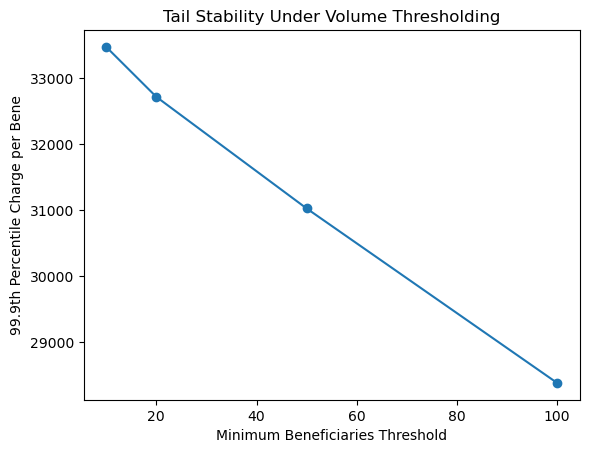

In [40]:
summary_df = pd.DataFrame(summary)

plt.plot(summary_df["Min Tot_Benes"], summary_df["99.9% Charge_per_Bene"], marker="o")
plt.xlabel("Minimum Beneficiaries Threshold")
plt.ylabel("99.9th Percentile Charge per Bene")
plt.title("Tail Stability Under Volume Thresholding")
plt.show()

In [38]:
race_pct_cols = [c.replace("_Cnt","_Pct") for c in race_cols]
df[race_pct_cols].isna().mean().sort_values(ascending=False)

Bene_Race_Othr_Pct      0.847514
Bene_Race_API_Pct       0.837335
Bene_Race_Hspnc_Pct     0.749949
Bene_Race_NatInd_Pct    0.713852
Bene_Race_Black_Pct     0.677478
Bene_Race_Wht_Pct       0.333492
dtype: float64

Race percentage variables are missing for a majority of providers, particularly for smaller racial categories. Any disparity modeling would require careful restriction or imputation.

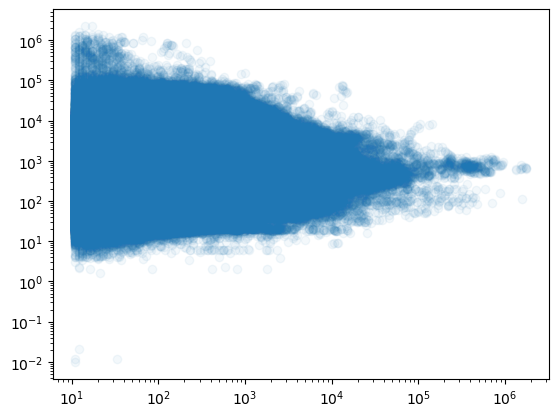

In [34]:
plt.scatter(df["Tot_Benes"], df["Charge_per_Bene"], alpha=0.05)
plt.xscale("log")
plt.yscale("log")
plt.show()

Spending variability decreases with provider volume, suggesting stabilization effects at larger scales.

In [16]:
df["Volume_Group"] = pd.qcut(df["Tot_Benes"], q=4, labels=["Small", "Mid-Small", "Mid-Large", "Large"])

df.groupby("Volume_Group")["Charge_per_Bene"].median()

C:\Users\alybo\AppData\Local\Temp\ipykernel_23332\3796373532.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Volume_Group")["Charge_per_Bene"].median()


Volume_Group
Small        593.090213
Mid-Small    652.630631
Mid-Large    704.987305
Large        674.789974
Name: Charge_per_Bene, dtype: float64

Per-beneficiary charges increase with provider size up to the mid-large segment, but slightly decrease among the largest providers, suggesting potential scale stabilization effects. This suggests a nonlinear relationship.